# 15d — Validation GLORIA dataset and comparison implementations

compare Inversion **bio_optics: hereon.forward()** with **bio_optics_dev: bi_jax** and **bio_optics_dev: bi**


In [1]:
%load_ext autoreload
%autoreload 2

import os
import time
import numpy as np
import xarray as xr
import lmfit
import matplotlib.pyplot as plt
import pandas as pd
import jax.numpy as jnp
import cmocean.cm as cm
from skimage.segmentation import mark_boundaries
from xcube.core.store import new_data_store
from suncalc import get_position, get_times
from sunpy.coordinates.sun import earth_distance

from bio_optics.water.reflectance import bi_jax, bi_fluo, lee, bi
from bio_optics.inversion import lmfit_engine
from bio_optics.image_processing import superpixel_engine
from bio_optics.water import absorption, attenuation, backscattering
from bio_optics.helper import resampling
from bio_optics.water.owt import OWT, OpticalVariables, owt_qwip_prepare

In [2]:
%reload_ext autoreload

In [3]:
def find_closest(arr: np.array, val: int):
  """ 
  Find the closest value to a number in an array.
  
  :param arr:  an array or list of numbers
  :param val:  the number  
  :return:     the closest value and its index in arr
  """
  arr = np.asarray(arr)
  idx = (np.abs(arr - val)).argmin()
  
  return arr[idx], idx

# Processing

## Configuration Bi & Hieronymi

In [4]:
regionName='GLORIA'
sensor = 'EnMAP'
versionAC = 'EnMAPWaterv1.5.2'
dataType = 'Insitu' #'EnMAPTile' # 'Sim'
## CAUTION: only Standardv2 is implemented here!! ##
AlgaeGroupType = 'Standardv2' #'Standardv2' # 'Standardv3' # 'NSSummerBloomsv3' Standardv2, 'HEREONgold'

# maxWavelength= 750.
maxWavelength = 850.
n_iter = 400

In [5]:
def set_default_parameters(AlgaeGroupType='Standardv3'):
    ## by Default:
    # - all Phytoplankton groups are value=0, min=0, max=1000 (C_5=10, C_7=1), vary = False
    # - C_Y value=0, min=0, max=30, vary=True
    # - C_ism value=0, min=0, max=100, vary=True
    # - fluorescence all vary = False
    # - offset vary = False
    params = lmfit.Parameters()                             # v3 ,      SummerBloom
    params.add('C_0', value=0, min=0, max=100, vary=False)  # Diatoms
    params.add('C_1', value=0, min=0, max=100, vary=False)  # green
    params.add('C_2', value=0, min=0, max=100, vary=False)  # cryptophyte
    params.add('C_3', value=0, min=0, max=100, vary=False)  # cyano blue
    params.add('C_4', value=0, min=0, max=100, vary=False)  # cyano red
    params.add('C_5', value=0, min=0, max=10, vary=False)   # coccolithophores , Phaeocystis: other ranges
    params.add('C_6', value=0, min=0, max=100, vary=False)  # dinoflagellates
    params.add('C_7', value=0, min=0, max=1, vary=False)    # case-1  , Noctiluca: other ranges
    params.add('C_Y', value=0, min=0, max=30, vary=False)
    params.add('C_ism', value=0, min=0, max=100, vary=False)
    params.add('L_fl_lambda0', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycocyanin', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycoerythrin', value=0, min=0, max=0.2, vary=False)
    params.add('b_ratio_C_0', value=0.002, vary=False)  # Diatoms 0.0058; HEREONweb: 0.002
    params.add('b_ratio_C_1', value=0.007, vary=False)  # green 0.007, HEREONweb: 0.007
    params.add('b_ratio_C_2', value=0.002, vary=False)  # cryptophyte 0.0042, HEREONweb: 0.002
    params.add('b_ratio_C_3', value=0.003, vary=False)  # cyano blue 0.0082, HEREONweb: 0.003
    params.add('b_ratio_C_4', value=0.003, vary=False)  # cyano red 0.001, HEREONweb: 0.003
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_5', value=0.0034, vary=False)  # Phaeocystis: change to 0.0034
    elif AlgaeGroupType == 'HEREONgold':
        params.add('b_ratio_C_5', value=0.002, vary=False)
    else:
        params.add('b_ratio_C_5', value=0.0129,
                   vary=False)  # coccolithophores 0.0129, , HEREONweb: 0.007, Phaeocystis: change to 0.0034
    params.add('b_ratio_C_6', value=0.0209, vary=False)  # dinoflagellates 0.0209, HEREONweb: not available
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_7', value=0.0209, vary=False)  # Noctiluca: change to 0.0209
    else:
        params.add('b_ratio_C_7', value=0.007,
                   vary=False)  # case-1 0.0109, HEREONweb: 0.007, Noctiluca: change to 0.0209
    params.add('b_ratio_md', value=0.0216, min=0.021, max=0.3756, vary=False)  # max=0.0756 #todo: vary turn off
    params.add('b_ratio_bd', value=0.0216, min=0.021, max=0.3756, vary=False)  # max=0.0756 #todo: vary turn off
    params.add('b_ratio_d', value=0.0216, min=0.021, max=0.3756, vary=False)
    params.add('A_md', value=13.4685e-3, vary=False)
    params.add('A_bd', value=0.3893e-3, vary=False)
    params.add('S_md', value=10.3845e-3, vary=False)
    params.add('S_bd', value=15.7621e-3, vary=False)
    params.add('S_cdom', value=0.020, min=0.018, max=0.022, vary=False) # Helsinki: 0.018 -0.022; test Baltic: min =0.01
    params.add('C_md', value=12.1700e-3, vary=False)
    params.add('C_bd', value=0.9994e-3, vary=False)
    params.add('K', value=0, min=0, vary=False)
    params.add('lambda_0_cdom', value=440, vary=False)
    params.add('lambda_0_md', value=550, vary=False)
    params.add('lambda_0_bd', value=550, vary=False)
    params.add('lambda_0_c_d', value=550, vary=False)
    params.add('lambda_0_phy', value=676, vary=False)
    params.add('gamma_d', value=0.3835, vary=False)
    params.add('x0', value=1, vary=False)
    params.add('x1', value=10, vary=False)
    params.add('x2', value=-1.3390, min=-1.3390 - 0.0618, max=-1.3390 + 0.0618, vary=False)
    params.add('A_phy', value=0.0237, vary=False)
    params.add('E0', value=1, vary=False)
    params.add('E1', value=0.8987, vary=False)
    params.add('W', value=0.75, vary=False)
    params.add('fwhm1', value=25, vary=False)
    params.add('fwhm2', value=50, vary=False)
    params.add('fwhm_phycocyanin', value=20, vary=False)
    params.add('fwhm_phycoerythrin', value=20, vary=False)
    params.add('lambda_C1', value=685, vary=False)
    params.add('lambda_C2', value=730, vary=False)
    params.add('lambda_C_phycocyanin', value=644, vary=False)
    params.add('lambda_C_phycoerythrin', value=573, vary=False)
    params.add('double', value=True, vary=False)
    params.add('interpolate', value=False, vary=False) # value=True
    params.add("Gw0", value=0.05881474, vary=False)
    params.add("Gw1", value=0.05062697, vary=False)
    params.add("Gp0", value=0.03997009, vary=False)
    params.add("Gp1", value=0.1398902, vary=False)
    params.add('error_method', value=0, vary=False)
    params.add('theta_sun', value=np.radians(30), min=np.radians(0), max=np.radians(90), vary=False)
    params.add('theta_view', value=np.radians(1e-10), min=np.radians(1e-10), max=np.radians(90), vary=False)
    params.add('n1', value=1, vary=False)
    params.add('n2', value=1.33, vary=False)
    params.add('kappa_0', value=1.0546, vary=False)
    params.add('fresh', value=False, vary=False)
    params.add('T_W', value=25, min=0, max=40, vary=False)
    params.add('T_W_0', value=20, vary=False)
    params.add('P', value=1013.25, vary=False)
    params.add('AM', value=1, vary=False)
    params.add('RH', value=60, vary=False)
    params.add('H_oz', value=0.38, vary=False)
    params.add('WV', value=2.5, vary=False)
    params.add('alpha', value=1.317, vary=False)
    params.add('beta', value=0.2606, vary=False)
    params.add('g_dd', value=0.02, min=-1, max=10, vary=False)  # glint correction
    params.add('g_dsr', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('g_dsa', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('d_r', value=0, min=0, max=0.1, vary=False)
    params.add('f_dd', value=1, vary=False)
    params.add('f_ds', value=1, vary=False)
    params.add('offset', value=0, min=-0.1, max=0.1, vary=False)
    params.add('fit_surface', value=False, vary=False)
    return params


def set_parameters_byDict(pDict, params):
    for key in pDict.keys():
        thisD = pDict[key]
        params.add(key, value=thisD['value'], min=thisD['min'], max=thisD['max'], vary=True)
    return params


def setDictValues(value, vmin, vmax):
    dd = {'value': value, 'min': vmin, 'max': vmax}
    return dd

In [6]:
## GLORIA setup for Inversion
processingDict_GLORIA = {
 '4a_y' : {
'C_0': setDictValues( 12.0 , 0., 925.39 ),
'C_1': setDictValues( 12.0 , 0., 925.39 ),
'C_2': setDictValues( 12.0 , 0., 925.39 ),
'C_3': setDictValues( 12.0 , 0., 925.39 ),
'C_4': setDictValues( 12.0 , 0., 925.39 ),
'C_5': setDictValues( 12.0 , 0., 925.39 ),
'C_6': setDictValues( 12.0 , 0., 925.39 ),
'C_7': setDictValues( 12.0 , 0., 925.39 ),
'C_ism': setDictValues( 3.6 , 0., 143.83 ),
'C_Y': setDictValues( 2.58 , 0., 19.74 )
},
'4b' : {
'C_0': setDictValues( 32.25 , 0., 481.85 ),
'C_1': setDictValues( 32.25 , 0., 481.85 ),
'C_2': setDictValues( 32.25 , 0., 481.85 ),
'C_3': setDictValues( 32.25 , 0., 481.85 ),
'C_4': setDictValues( 32.25 , 0., 481.85 ),
'C_5': setDictValues( 32.25 , 0., 481.85 ),
'C_6': setDictValues( 32.25 , 0., 481.85 ),
'C_7': setDictValues( 32.25 , 0., 481.85 ),
'C_ism': setDictValues( 19.06 , 0., 1195.75 ),
'C_Y': setDictValues( 1.36 , 0., 11.21 )
},
'5a' : {
'C_0': setDictValues( 24.26 , 0., 351.72 ),
'C_1': setDictValues( 24.26 , 0., 351.72 ),
'C_2': setDictValues( 24.26 , 0., 351.72 ),
'C_3': setDictValues( 24.26 , 0., 351.72 ),
'C_4': setDictValues( 24.26 , 0., 351.72 ),
'C_5': setDictValues( 24.26 , 0., 351.72 ),
'C_6': setDictValues( 24.26 , 0., 351.72 ),
'C_7': setDictValues( 24.26 , 0., 351.72 ),
'C_ism': setDictValues( 10.75 , 0., 159.06 ),
'C_Y': setDictValues( 1.31 , 0., 11.27 )
},
'5b' : {
'C_0': setDictValues( 16.03 , 0., 323.53 ),
'C_1': setDictValues( 16.03 , 0., 323.53 ),
'C_2': setDictValues( 16.03 , 0., 323.53 ),
'C_3': setDictValues( 16.03 , 0., 323.53 ),
'C_4': setDictValues( 16.03 , 0., 323.53 ),
'C_5': setDictValues( 16.03 , 0., 323.53 ),
'C_6': setDictValues( 16.03 , 0., 323.53 ),
'C_7': setDictValues( 16.03 , 0., 323.53 ),
'C_ism': setDictValues( 10.84 , 0., 113.56 ),
'C_Y': setDictValues( 0.62 , 0., 6.29 )
},
'6' : {
'C_0': setDictValues( 41.73 , 0., 1334.63 ),
'C_1': setDictValues( 41.73 , 0., 1334.63 ),
'C_2': setDictValues( 41.73 , 0., 1334.63 ),
'C_3': setDictValues( 41.73 , 0., 1334.63 ),
'C_4': setDictValues( 41.73 , 0., 1334.63 ),
'C_5': setDictValues( 41.73 , 0., 1334.63 ),
'C_6': setDictValues( 41.73 , 0., 1334.63 ),
'C_7': setDictValues( 41.73 , 0., 1334.63 ),
'C_ism': setDictValues( 24.9 , 0., 410.04 ),
'C_Y': setDictValues( 0.87 , 0., 6.26 )
},
'7' : {
'C_0': setDictValues( 15.37 , 0., 121.99 ),
'C_1': setDictValues( 15.37 , 0., 121.99 ),
'C_2': setDictValues( 15.37 , 0., 121.99 ),
'C_3': setDictValues( 15.37 , 0., 121.99 ),
'C_4': setDictValues( 15.37 , 0., 121.99 ),
'C_5': setDictValues( 15.37 , 0., 121.99 ),
'C_6': setDictValues( 15.37 , 0., 121.99 ),
'C_7': setDictValues( 15.37 , 0., 121.99 ),
'C_ism': setDictValues( 3.55 , 0., 18.26 ),
'C_Y': setDictValues( 1.17 , 0., 6.86 )
},
'NaN' : {
'C_0': setDictValues( 2.02 , 0., 42.09 ),
'C_1': setDictValues( 2.02 , 0., 42.09 ),
'C_2': setDictValues( 2.02 , 0., 42.09 ),
'C_3': setDictValues( 2.02 , 0., 42.09 ),
'C_4': setDictValues( 2.02 , 0., 42.09 ),
'C_5': setDictValues( 2.02 , 0., 42.09 ),
'C_6': setDictValues( 2.02 , 0., 42.09 ),
'C_7': setDictValues( 2.02 , 0., 42.09 ),
'C_ism': setDictValues( 3.02 , 0., 90.08 ),
'C_Y': setDictValues( 0.15 , 0., 8.08 )
}
}

In [7]:
### Standard NorthSea ## -> Not good for GLORIA
processingDict_NorthSea = {
    '1': {'C_7': setDictValues(0,0,1)},
    '2': {'C_0': setDictValues(0,0,1),
          'C_2': setDictValues(0,0,1),
          'C_3': setDictValues(0,0,1), # Synechococcus
          'C_6': setDictValues(0,0,1),
          'C_7': setDictValues(0,0,1),
          'C_Y': setDictValues(0,0,0.1),
          'C_ism': setDictValues(0,0,1)}, # no fluorescence!
    '3a': {'C_0': setDictValues(0.1,0,10),
          'C_2': setDictValues(0,0,10),
           'C_3': setDictValues(0,0,10), # Synechococcus
          'C_4': setDictValues(0,0,10),
           'C_6': setDictValues(0,0,10),
          'C_Y': setDictValues(0,0,1),
          'C_ism': setDictValues(0,0,10),
           # 'L_fl_lambda0': setDictValues(0,0,0.2),
           # 'L_fl_phycoerythrin': setDictValues(0,0,0.2),
           #  'L_fl_phycocyanin': setDictValues(0,0,0.2)
           },
    '3a_g': {'C_0': setDictValues(0.1,0,10),
          'C_2': setDictValues(0,0,10),
           'C_3': setDictValues(0,0,10), # Synechococcus
          'C_4': setDictValues(0,0,10),
           'C_6': setDictValues(0,0,10),
          'C_Y': setDictValues(0,0,1),
          'C_ism': setDictValues(0,0,10),
           # 'L_fl_lambda0': setDictValues(0,0,0.2),
           # 'L_fl_phycoerythrin': setDictValues(0,0,0.2),
           #  'L_fl_phycocyanin': setDictValues(0,0,0.2)
           },
    '3a_y': {'C_0': setDictValues(0.1,0,10),
          'C_2': setDictValues(0,0,10),
           'C_3': setDictValues(0,0,10), # Synechococcus
          'C_4': setDictValues(0,0,10),
           'C_6': setDictValues(0,0,10),
          'C_Y': setDictValues(0,0,3),
          'C_ism': setDictValues(0,0,10),
           # 'L_fl_lambda0': setDictValues(0,0,0.2),
           # 'L_fl_phycoerythrin': setDictValues(0,0,0.2),
           #  'L_fl_phycocyanin': setDictValues(0,0,0.2)
           },
    '3b': {'C_0': setDictValues(0.1,0,10),
          'C_2': setDictValues(0,0,10),
           'C_5': setDictValues(0,0,10), # coccolith.
          'C_6': setDictValues(0,0,10),
          'C_Y': setDictValues(0,0,3),
          'C_ism': setDictValues(0,0,10),
           # 'L_fl_lambda0': setDictValues(0,0,0.2),
           # 'L_fl_phycoerythrin': setDictValues(0,0,0.2)
           },
    '4a': {'C_0': setDictValues(0.1,0,30),
        # 'C_1': setDictValues(0,0,30),
          'C_2': setDictValues(0,0,30),
           'C_3': setDictValues(0,0,30), # Synechococcus
          'C_4': setDictValues(0,0,30),
          'C_6': setDictValues(0,0,30),
          'C_Y': setDictValues(0,0,3),
          'C_ism': setDictValues(0,0,20),
           # 'L_fl_lambda0': setDictValues(0,0,0.2),
           # 'L_fl_phycoerythrin': setDictValues(0,0,0.2),
           # 'L_fl_phycocyanin': setDictValues(0,0,0.2)
           },
    '4a_g': {'C_0': setDictValues(0.1,0,30),
            # 'C_1': setDictValues(0,0,30),
          'C_2': setDictValues(0,0,30),
           'C_3': setDictValues(0,0,30), # Synechococcus
          'C_4': setDictValues(0,0,30),
          'C_6': setDictValues(0,0,30),
          'C_Y': setDictValues(0,0,3),
          'C_ism': setDictValues(0,0,20),
           # 'L_fl_lambda0': (0,0,0.2),
           # 'L_fl_phycoerythrin': setDictValues(0,0,0.2),
           # 'L_fl_phycocyanin': setDictValues(0,0,0.2)
             },
    '4a_y': {'C_0': setDictValues(0.1,0,30),
        # 'C_1': setDictValues(0,0,30),
          'C_2': setDictValues(0,0,30),
           'C_3': setDictValues(0,0,30), # Synechococcus
          'C_4': setDictValues(0,0,30),
          'C_6': setDictValues(0,0,30),
          'C_Y': setDictValues(0,0,3),
          'C_ism': setDictValues(0,0,20),
           # 'L_fl_lambda0': setDictValues(0,0,0.2),
           # 'L_fl_phycoerythrin': setDictValues(0,0,0.2),
           # 'L_fl_phycocyanin': setDictValues(0,0,0.2)
             },
    '4b': {'C_0': setDictValues(0.1,0,300),
        # 'C_1': setDictValues(0,0,100),
          'C_2': setDictValues(0,0,300),
        'C_3': setDictValues(0,0,100), # Synechococcus
          'C_4': setDictValues(0,0,100),
            'C_5': setDictValues(0,0,10), # coccolith.
          'C_6': setDictValues(0,0,300),
          'C_Y': setDictValues(0,0,3),
          'C_ism': setDictValues(0,0,100),
           # 'L_fl_lambda0': setDictValues(0,0,0.2),
           # 'L_fl_phycoerythrin': setDictValues(0,0,0.2),
           # 'L_fl_phycocyanin': setDictValues(0,0,0.2)
           },
    '5a': {'C_0': setDictValues(0.,0,300),
           # 'C_1': setDictValues(0,0,300),
          'C_2': setDictValues(0,0,300),
           'C_3': setDictValues(0,0,300), # Synechococcus
          'C_4': setDictValues(0,0,300),
           'C_6': setDictValues(0,0,300),
          'C_Y': setDictValues(0,0,3),
          'C_ism': setDictValues(0,0,100),
           # 'L_fl_lambda0': setDictValues(0,0,0.2),
           #  'L_fl_phycoerythrin': setDictValues(0,0,0.2),
           #  'L_fl_phycocyanin': setDictValues(0,0,0.2)
           # 'offset': setDictValues(0, -0.1, 0.1)
           },
    '5b': {'C_0': setDictValues(0.1,0,1000),
            # 'C_1': setDictValues(0.1,0,100),
          'C_2': setDictValues(0,0,1000),
            'C_3': setDictValues(0,0,300), # Synechococcus
          'C_4': setDictValues(0,0,300),
          'C_6': setDictValues(0,0,1000),
          'C_Y': setDictValues(0,0,3),
          'C_ism': setDictValues(0,0,100),
           # 'L_fl_lambda0': setDictValues(0,0,0.2),
           #  'L_fl_phycoerythrin': setDictValues(0,0,0.2),
           #  'L_fl_phycocyanin': setDictValues(0,0,0.2)
           # 'offset': setDictValues(0, -0.1, 0.1)
           },
    '6': {'C_0': setDictValues(0.1,0,500),
          # 'C_1': setDictValues(0.,0,500),
          'C_2': setDictValues(0,0,500),
            'C_3': setDictValues(0,0,300), # Synechococcus
          'C_4': setDictValues(0,0,300),
          'C_6': setDictValues(0,0,500),
          'C_Y': setDictValues(0,0,3),
          'C_ism': setDictValues(0,0,1000),
           # 'L_fl_lambda0': setDictValues(0,0,0.2),
          # 'L_fl_phycoerythrin': setDictValues(0,0,0.2),
          # 'L_fl_phycocyanin': setDictValues(0,0,0.2)
          },
    '7': {'C_0': setDictValues(0.1,0,200),
          'C_1': setDictValues(0.,0,200),
          'C_2': setDictValues(0,0,200),
            'C_3': setDictValues(0,0,200), # Synechococcus
          'C_4': setDictValues(0,0,200),
          'C_6': setDictValues(0,0,200),
          'C_Y': setDictValues(0,0,3),
          'C_ism': setDictValues(0,0,100),
           # 'L_fl_lambda0': setDictValues(0,0,0.2),
          # 'L_fl_phycoerythrin': setDictValues(0,0,0.2),
          # 'L_fl_phycocyanin': setDictValues(0,0,0.2)
          }
}

# Validation with GLORIA
Read GLORIA spectra, calculate OWTs and run inversion

## Read data

In [7]:
# pathGLORIA = "E:\Documents\projects\EnsAD\insitu_data\GLORIA\GLORIA_Rrs_mean_Convolved_EnMAP2.csv"
pathGLORIA = "Z:\projects\ongoing\AQUATIME\sharepoint\WP3 Product Engineering\InversionPhytoplanktonGroups\\validation\insitu\GLORIA_Rrs_mean_Convolved_EnMAP2.csv"
# here: ending in EnMAP2.csv -> GLORIA_Rrs.csv, ending in EnMAP.csv -> GLORIA_Rrs_mean.csv
Rrs = pd.read_csv(pathGLORIA, header=0, sep='\t')
header = Rrs.columns.values

# spath = "E:\Documents\projects\EnsAD\c2rcc_test\EnMAP_SRF\EnMAP_Spectral_Bands.txt"
spath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP3 Product Engineering\InversionPhytoplanktonGroups\\validation\EnMAP\EnMAP_Spectral_Bands.txt"
s = pd.read_csv(spath, sep='\t', header=0)
# print(s.iloc[:, 1].values)
wlGLORIA = s.iloc[:, 1].values
ID = wlGLORIA < maxWavelength
wlGLORIA = wlGLORIA[ID]
Rrs_col = ['band_%03i' % (i + 1) for i in range(len(wlGLORIA))]


In [8]:
## GLORIA insitu concentrations
# iopGLORIApath = "E:\Documents\projects\EnsAD\insitu_data\GLORIA\\"
iopGLORIApath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP3 Product Engineering\InversionPhytoplanktonGroups\\validation\insitu\\"
iopGLORIA = pd.read_csv(iopGLORIApath + "GLORIA_meta_and_lab.csv", header=0, sep=',')
# print(iopGLORIA.columns.values)

In [9]:
wavelengths = wlGLORIA
sp_spectra = Rrs[Rrs_col].values
valid = np.ones(Rrs.shape[0]) == 1

## Step 1.2 - Calculate OWT

In [10]:
AVW, NDI, qwip_score = owt_qwip_prepare.calculate_QWIP_hyperspectral(Rrs=sp_spectra[valid,:], wl_=wavelengths, maxwl=700)
Area = owt_qwip_prepare.calculate_area(Rrs=sp_spectra[valid,:], band=wavelengths)
fn_centroids = "../bio_optics/water/owt/data/OWT_centroids_refined3a_4a_final.nc"
# fn_centroids = "../bio_optics/water/owt/data/OWT_centroids.nc"
owt = OWT.OWT(AVW, Area, NDI, fn_centroids)
owt.run_classification()

membership = owt.u
colorMapDict = owt.dict_idx_color
classNames = owt.dict_idx_name
owt_result_str = owt.type_str
owt_result = owt.type_idx
owt_names = [b for b in owt.dict_idx_name.values()]

membership = owt.u[0]

membSum = np.sum(membership, axis=1)
highMemb = np.sum(membership > 0.5, axis=1)
medMemb = np.sum(np.logical_and(membership > 0.2, membership < 0.5), axis=1)
lowMemb = np.sum(np.logical_and(membership > 0.01, membership < 0.2), axis=1)

outDF = pd.DataFrame()
outDF['AVW'] = AVW
outDF['Area'] = Area
outDF['NDI'] = NDI
outDF['OWT'] = owt_result[0,:]
outDF['OWTstr'] = owt_result_str[0,:]
outDF['membSum'] = membSum

(7572, 72)
[ 4 28 46]
[441.98 558.25 663.11]
(7572, 3)


### Setup GLORIA processing dictionary
Use the insitu values per OWT: median as start value, 99% as max value, min value= 0.

In [75]:
## force minimum value to 0.
for o in np.unique(outDF.OWTstr):
    ID = outDF.OWTstr == o
    print('\''+ o + '\' : {')
    chlv = np.round(np.nanpercentile(iopGLORIA['Chla'].values[ID], [50, 0, 99]),2)
    for i in range(8):
        print( '\'C_'+str(i) + '\': setDictValues(', chlv[0], ', 0.,', chlv[2]  , '),')
    tssv = np.round(np.nanpercentile(iopGLORIA['TSS'].values[ID], [50, 0, 99]),2)
    yv = np.round(np.nanpercentile(iopGLORIA['aCDOM440'].values[ID], [50, 0, 99]),2)
    print('\'C_ism\': setDictValues(', tssv[0], ', 0.,', tssv[2] , '),\n'
          '\'C_Y\': setDictValues(',   yv[0], ', 0.,', yv[2] , ')')
    print('},')

'4a_y' : {
'C_0': setDictValues( 12.0 , 0., 925.39 ),
'C_1': setDictValues( 12.0 , 0., 925.39 ),
'C_2': setDictValues( 12.0 , 0., 925.39 ),
'C_3': setDictValues( 12.0 , 0., 925.39 ),
'C_4': setDictValues( 12.0 , 0., 925.39 ),
'C_5': setDictValues( 12.0 , 0., 925.39 ),
'C_6': setDictValues( 12.0 , 0., 925.39 ),
'C_7': setDictValues( 12.0 , 0., 925.39 ),
'C_ism': setDictValues( 3.6 , 0., 143.83 ),
'C_Y': setDictValues( 2.58 , 0., 19.74 )
},
'4b' : {
'C_0': setDictValues( 32.25 , 0., 481.85 ),
'C_1': setDictValues( 32.25 , 0., 481.85 ),
'C_2': setDictValues( 32.25 , 0., 481.85 ),
'C_3': setDictValues( 32.25 , 0., 481.85 ),
'C_4': setDictValues( 32.25 , 0., 481.85 ),
'C_5': setDictValues( 32.25 , 0., 481.85 ),
'C_6': setDictValues( 32.25 , 0., 481.85 ),
'C_7': setDictValues( 32.25 , 0., 481.85 ),
'C_ism': setDictValues( 19.06 , 0., 1195.75 ),
'C_Y': setDictValues( 1.36 , 0., 11.21 )
},
'5a' : {
'C_0': setDictValues( 24.26 , 0., 351.72 ),
'C_1': setDictValues( 24.26 , 0., 351.72 ),
'C_2': s

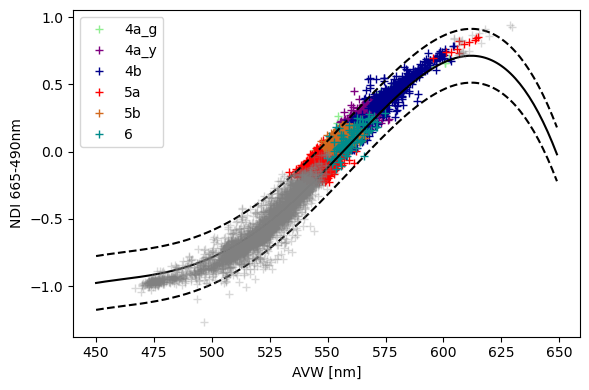

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax = owt_qwip_prepare.plot_QWIP_AVW_byOWT(NDI, AVW, outDF, owt_names, colorMapDict, ax)
ID = outDF['OWTstr'] == 'NaN'
if np.sum(ID)>0:
    ax.plot(AVW[ID], NDI[ID], '+', color='gray', alpha=0.3)
fig.tight_layout()
plt.show()

### Step 1.2 — Write spectra to file with OWT

In [47]:
## write mean spectra to file
import pandas as pd
valid = np.where(np.sum(np.logical_not(np.isnan(sp_spectra)), axis=1)>0)[0]
outdf = pd.DataFrame(sp_spectra[valid,:], columns=[str(a) for a in wavelengths])
outdf['OWT'] = owt_result_str[0,:]

outpath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP3 Product Engineering\InversionPhytoplanktonGroups\\validation\insitu\\"
# outpath = "D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\\"
outdf.to_csv(outpath + 'ValidationGLORIA_withOWTrefined.txt',  sep='\t', header=True, index=False)

## Step 2 — Least Square inversion of spectra

### ToDo: Angle dependency in GLORIA

### Inversion with OWT and Ray

In [12]:
def create_chunks(data):
    if data.shape[0] < 100:
        num_chunks = 1
    elif data.shape[0] < 1000:
        num_chunks = 3
    else:
        num_chunks = 9  # Number of chunks to split the DF into

    chunk_size = data.shape[0] // num_chunks  # Size of each chunk
    chunks = [data[i:i + chunk_size, :] for i in range(0, data.shape[0], chunk_size)]  # Split the DF into chunks
    while chunks[-1].shape[0] == 1 and num_chunks>0:
        num_chunks -= 1
        if num_chunks >0:
            # print(data.shape[0],  num_chunks)
            chunk_size = data.shape[0] // num_chunks  # Size of each chunk
            chunks = [data[i:i + chunk_size, :] for i in  range(0, data.shape[0], chunk_size)]  # Split the DF into chunks
        else:
            chunks = [data]

    print(chunks[-1].shape[0])
    print('chunks N', len(chunks))
    return chunks

In [14]:
angle_dependency = False

# --- precompute --------------------------
pre_base     = bi_jax.precompute(wavelengths)
pre = {**pre_base}

def forward_func(params, wavelengths):
    """Adapter: lmfit_engine signature → bi_jax.forward."""
    return np.array(bi_jax.forward(params, pre))
    # return np.array(bi_fluo.forward(params, pre)) # TODO: does not work yet!

## --- per OWT ###
OWTList = [ '1', '2', '3a', '3a_g', '3a_y', '3b', '4a', '4a_g', '4a_y', '4b', '5a', '5b', '6', '7', 'NaN']

## check all occuring varying parameters
parList = []
for owt in OWTList:
    if owt in list(processingDict_GLORIA.keys()):
        for p in processingDict_GLORIA[owt].keys():
            parList.append(p)
parList = np.unique(parList)
print(parList)

['C_0' 'C_1' 'C_2' 'C_3' 'C_4' 'C_5' 'C_6' 'C_7' 'C_Y' 'C_ism']


In [16]:
import ray

noise = 1
sp_results = pd.DataFrame(np.zeros((len(valid), len(parList))) + np.nan, columns = parList)

for owt in OWTList[:]:
    ID = outDF.OWTstr == owt
    print(owt, np.sum(ID))
    if np.sum(ID)>0:
        rrs_sub = sp_spectra[valid,:][ID,:]
        counts_sub = 10. #sp_counts[valid][ID]
        paramDict = processingDict_GLORIA[owt]
        thisParamList = list(processingDict_GLORIA[owt].keys())
        params = set_default_parameters(AlgaeGroupType)
        params = set_parameters_byDict(paramDict, params)

        # if angle_dependency:
        #     params.add("Gw0", value=G0w, vary=False)
        #     params.add("Gw1", value=G1w, vary=False)
        #     params.add("Gp0", value=G0p, vary=False)
        #     params.add("Gp1", value=G1p, vary=False)

        setup = lmfit_engine.build_inversion(
                        params,
                        wavelengths,
                        forward_func,
                        method='least-squares',
                        max_nfev=n_iter,
                    )

        @ray.remote
        def invert_chunk(chunk,
                         counts_sub,
                         setup,
                         noise):

            # make a copy of actual params object to enable in-parallel mutation
            # chunk_setup = setup

            # for i in np.arange(chunk.shape[0]):
            inv = superpixel_engine.invert_superpixels(
                    chunk, counts_sub, setup, noise,
                    invert_fn = lmfit_engine.invert_image,
                    # max_steps=100, tile_size=tile_size
                )
                # results[i] = inv['x_hat'][:]

            return inv['x_hat'] # results

        data = rrs_sub
        chunks = create_chunks(data)

        ray.shutdown()

        # Parallelize the processing of the chunks using ray
        chunk_refs = [ray.put(chunk) for chunk in chunks]  # Put the chunks into the object store
        result_refs = [invert_chunk.remote(chunk_ref,
                                           counts_sub,
                                           setup=setup,
                                           noise=noise

                                           ) for chunk_ref in chunk_refs]  # Process the chunks in parallel

        results = ray.get(result_refs)

        # Concatenate the results from the processed chunks
        processed_data = np.concatenate(results)
        results = processed_data

        for fn in thisParamList:
            y = np.array(sp_results[fn].values)
            i = np.where(np.asarray(setup.fit_names) == fn)[0][0]
            y[ID] = results[:, i]
            sp_results[fn] = y

        outpath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP3 Product Engineering\InversionPhytoplanktonGroups\\validation\FullInversion_bio-optics_dev-bi_jax\\"
        sp_results.to_csv(outpath + "invertedIOPs_Bi_jax_GLORIA_OWTrefined_GLORIA_withOWTNaNclass_OWT"+owt+".txt", header=True,
                          index=False)

1 0
2 0
3a 0
3a_g 0
3a_y 0
3b 0
4a 0
4a_g 0
4a_y 75
75
chunks N 1


2026-05-22 13:44:36,389	INFO worker.py:2012 -- Started a local Ray instance.


4b 802
401
chunks N 2


2026-05-22 13:46:32,838	INFO worker.py:2012 -- Started a local Ray instance.


5a 813
271
chunks N 3


...

2026-05-22 14:06:16,849	INFO worker.py:2012 -- Started a local Ray instance.


7 112
56
chunks N 2


2026-05-22 14:12:41,928	INFO worker.py:2012 -- Started a local Ray instance.


NaN 3210
6
chunks N 10


2026-05-22 14:14:08,318	INFO worker.py:2012 -- Started a local Ray instance.


### Analysis inversion

In [17]:
Rrs_sim_jax_Arr = np.zeros((len(valid), len(wavelengths)))

for i in range(sp_results.shape[0]):
    if not np.all(np.isnan(sp_results.iloc[i].values)):
        for j, p in enumerate(sp_results.columns.values):
            # Change parameters object accordingly.
            # if p.startswith('C_'):
            #     print(p, np.round(paramDF[p].values[i] / invIOP['C_phy'].values[i], 2))
            if not np.isnan(sp_results[p].values[i]):
                params.add(p, value=sp_results[p].values[i])
            else:
                params.add(p, value=0.)

        R_rs_sim_jax = bi_jax.forward(params, pre)
        Rrs_sim_jax_Arr[i,:] = R_rs_sim_jax

In [18]:
## Write to file
# outpath = "D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\FullInversion\\"
outpath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP3 Product Engineering\InversionPhytoplanktonGroups\\validation\FullInversion_bio-optics_dev-bi_jax\\"
sp_results.to_csv(outpath + "invertedIOPs_Bi_jax_GLORIA_OWTrefined_GLORIA_withOWTNaNclass.txt", header=True, index=False)
for i,w in enumerate(wavelengths):
    outDF[str(w)] = Rrs_sim_jax_Arr[:, i]
outDF.to_csv(outpath + "invertedRrs_Bi_jax_GLORIA_OWTrefined_GLORIA_withOWTNaNclass.txt", header=True, index=False)


## Compare results

In [19]:
##
## GLORIA Validation: read full inversion old way. Max_iter = 1500! Still a lot faster than this bi_jax version!
import pandas as pd
# inpath = "D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\FullInversion\\"
inpath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP3 Product Engineering\InversionPhytoplanktonGroups\\validation\FullInversion_bio-optics-hereon\\"
fnames = os.listdir(inpath)
## b: with fluorescence, c: no fluorescence, d: no variation in b_ratio_bd, S_cdom
# inverted_IOP_bio_optics_HEREONfull_ValidationGLORIA_withOWTrefined_allOWTs_GLORIAbounds_Inv0.1d.txt: includes inversion of all spetra with OWT NaN, which are perfectly fine according to QWIP!
rrsFname = [fn for fn in fnames if fn.startswith('inverted_Sim') and fn.endswith('d.txt') and 'GLORIAbounds' in fn][0]
print(rrsFname)
invRrs = pd.read_csv(inpath+ rrsFname, header=0)
invWL = np.asarray([float(a) for a in invRrs.columns.values])
iopFname = [fn for fn in fnames if fn.startswith('inverted_IOP') and fn.endswith('d.txt') and 'GLORIAbounds' in fn][0]

invIOP =  pd.read_csv(inpath+ iopFname, header=0)
print(invIOP.shape)
print(invRrs.shape)

inverted_Sim_bio_optics_HEREONfull_ValidationGLORIA_withOWTrefined_allOWTs_GLORIAbounds_Inv0.1d.txt
(7572, 84)
(7572, 72)


In [53]:
## full inversion bi lmfit_engine (in python)
# inpath = "D:\Documents\projects\EnsAD\EnMAP\dask_oe_processor_2026\FullInversion\\"
inpath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP3 Product Engineering\InversionPhytoplanktonGroups\\validation\FullInversion_bio-optics-dev-bi\\"
iopTest = pd.read_csv(inpath + "invertedIOPs_Bi_GLORIA_OWTrefined_GLORIA_withOWTNaNclass_OWT5b_b.txt", header=0)
# iopTest.rename(columns={'C_ism': 'C_Y_new', 'C_Y': 'C_ism', 'C_Y_new': 'C_Y'}, inplace=True)
iopTest2 = pd.read_csv(inpath + "invertedIOPs_Bi_GLORIA_OWTrefined_GLORIA_withOWTNaNclass_OWTNaN_b.txt", header=0) # had to be inverted in two parts, error for OWT 6
owtList = ['7', 'NaN']
for owt in owtList:
    ID = outDF.OWTstr == owt
    for col in iopTest.columns.values:
        y = np.array(iopTest[col].values)
        y[ID] = iopTest2[col].values[ID]
        iopTest[col] = y

## run forward
## --- setup bi forward ---
a_md_spec_res = absorption.a_md_spec(wavelengths=wavelengths)
a_bd_spec_res = absorption.a_bd_spec(wavelengths=wavelengths)
a_w_res = absorption.a_w(wavelengths=wavelengths)
# if AlgaeGroupType == 'Standardv2':
a_i_spec_res = resampling.resample_a_i_spec_EnSAD(wavelengths=wavelengths) # prototype v2, PACEv2
b_bw_res = backscattering.bb_w(wavelengths=wavelengths, fresh=False)
b_i_spec_res = resampling.resample_b_i_spec_EnSAD(wavelengths=wavelengths) # prototype v2, PACEv2
da_w_div_dT_res = absorption.da_w_div_dT(wavelengths=wavelengths)
omega_d_lambda_0_res = attenuation.omega_d_lambda_0()
n2_res = resampling.resample_n(wavelengths=wavelengths)

def forward_func(params, wavelengths):
    return np.array(bi.forward(params,
                               wavelengths,
                               omega_d_lambda_0_res=omega_d_lambda_0_res,
                               a_md_spec_res=a_md_spec_res,
                               a_bd_spec_res=a_bd_spec_res,
                               a_w_res=a_w_res,
                               a_i_spec_res=a_i_spec_res,
                               da_w_div_dT_res=da_w_div_dT_res,
                               bb_w_res=b_bw_res,
                               bb_i_spec_res=b_i_spec_res,
                               n2_res=n2_res
                               ))

Rrs_sim_Arr = np.zeros((len(valid), len(wavelengths)))

for i in range(iopTest.shape[0]):
    if not np.all(np.isnan(iopTest.iloc[i].values)):
        for j, p in enumerate(iopTest.columns.values):
            # Change parameters object accordingly.
            if not np.isnan(iopTest[p].values[i]):
                params.add(p, value=iopTest[p].values[i])
            else:
                params.add(p, value=0.)

        R_rs_sim = forward_func(params, wavelengths)
        Rrs_sim_Arr[i,:] = R_rs_sim

802
4411
bi_jax C_0      10.652960
C_1      36.217067
C_2       8.396204
C_3       0.302461
C_4       1.828383
C_5       1.245454
C_6       1.570658
C_7       0.000733
C_Y       1.934033
C_ism    15.483468
Name: 4411, dtype: float64
bi C_0       1.548
C_1       0.011
C_2       0.219
C_3       2.814
C_4       2.489
C_5       0.092
C_6       0.010
C_7       0.118
C_Y       1.191
C_ism    15.519
Name: 4411, dtype: float64
hereon C_0       0.000
C_1       0.000
C_2       0.000
C_3       1.997
C_4       1.303
C_5       0.000
C_6       4.675
C_7       0.000
C_Y       1.103
C_ism    15.686
Name: 4411, dtype: float64


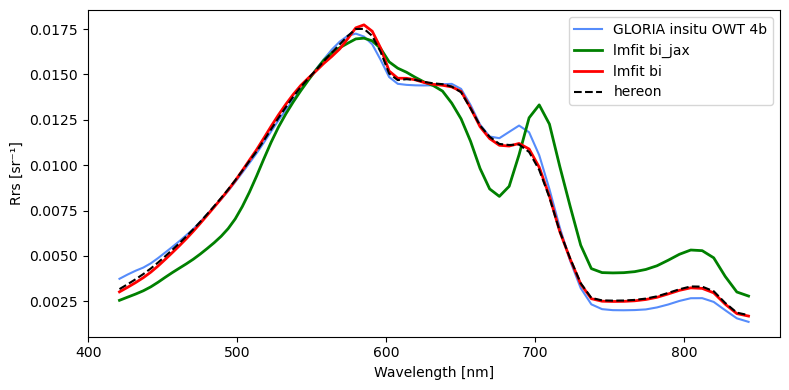

In [36]:
indOWT = np.where(outDF.OWTstr == '4b')[0]
print(len(indOWT))
i = indOWT[500]
print(i)
vi = i
print('bi_jax', sp_results.iloc[i, :])
print('bi', np.round(iopTest[sp_results.columns.values].iloc[i, :], 3))
print('hereon', np.round(invIOP[sp_results.columns.values].iloc[i, :], 3))

# print(invIOP['S_cdom'].iloc[i])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wavelengths, sp_spectra[valid,:][i,:], '-', label='GLORIA insitu OWT '+ outDF['OWTstr'].values[i])
ax.plot(wavelengths, Rrs_sim_jax_Arr[i,:], 'g-', lw=2, label='lmfit bi_jax')
ax.plot(wavelengths, Rrs_sim_Arr[i,:], 'r-', lw=2, label='lmfit bi')
ax.plot(invWL, invRrs.iloc[vi,:], 'k--',  label='hereon')

ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Rrs [sr⁻¹]')
ax.legend()
plt.tight_layout()
plt.show()

In [61]:
sp_results['C_phy'] = np.nansum(sp_results[['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_6', 'C_7']].values, axis=1)

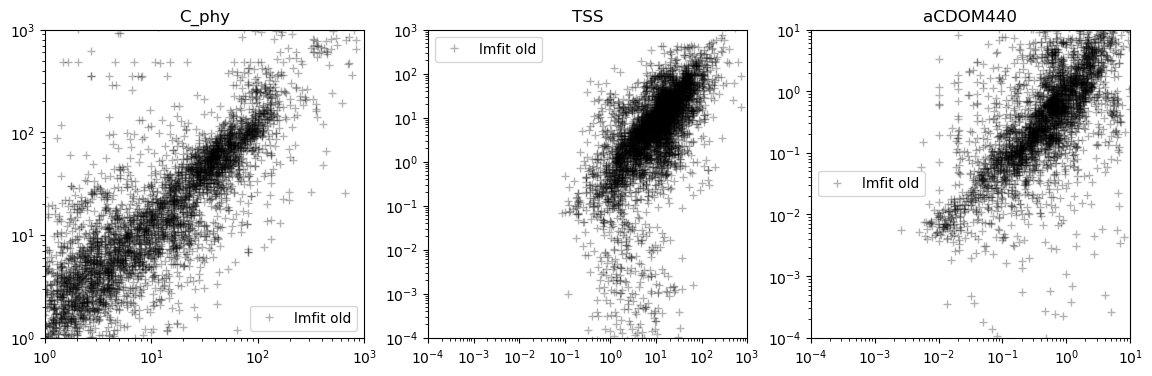

In [77]:
fig, ax = plt.subplots(ncols=3, figsize=(14, 4))
ax[0].loglog(iopGLORIA['Chla'].values, invIOP['C_phy'].values, 'k+', alpha=0.3, label='lmfit old')
# ax[0].loglog(iopGLORIA['Chla'].values, sp_results['C_phy'].values, 'g+', alpha=0.3, label='lmfit bi_jax')
ax[0].set_xlim([1, 1000])
ax[0].set_ylim([1, 1000])
ax[0].set_title('C_phy')
ax[0].legend()
ax[1].loglog(iopGLORIA['TSS'].values, invIOP['C_ism'].values, 'k+', alpha=0.3, label='lmfit old')
# ax[1].loglog(iopGLORIA['TSS'].values, sp_results['C_ism'].values, 'g+', alpha=0.3, label='lmfit bi_jax')
ax[1].set_xlim([0.0001, 1000])
ax[1].set_ylim([0.0001, 1000])
ax[1].legend()
ax[1].set_title('TSS')
ax[2].loglog(iopGLORIA['aCDOM440'].values, invIOP['C_Y'].values, 'k+', alpha=0.3, label='lmfit old')
# ax[2].loglog(iopGLORIA['aCDOM440'].values, sp_results['C_Y'].values, 'g+', alpha=0.3, label='lmfit bi_jax')
ax[2].set_xlim([0.0001, 10])
ax[2].set_ylim([0.0001, 10])
ax[2].legend()
ax[2].set_title('aCDOM440')
plt.show()

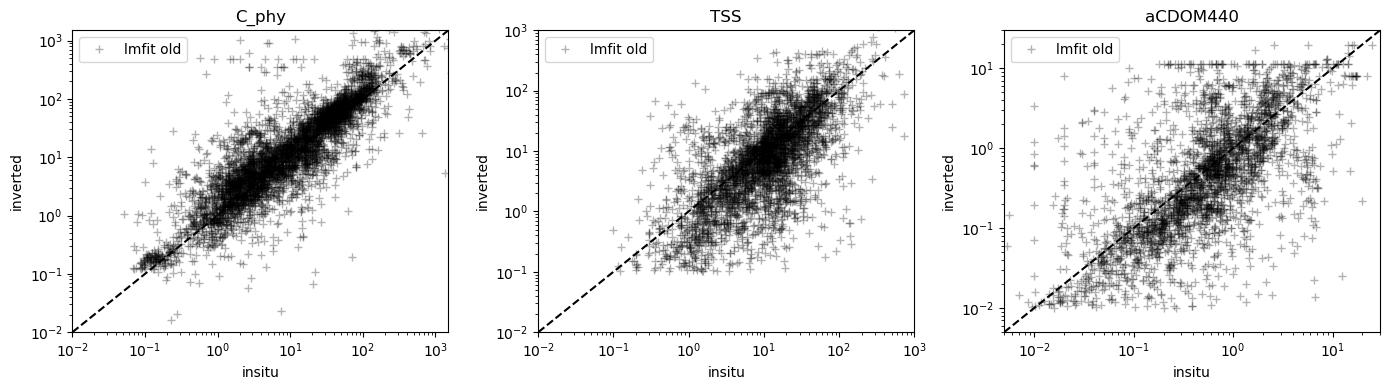

In [79]:
fig, ax = plt.subplots(ncols=3, figsize=(14, 4))

ax[0].loglog(iopGLORIA['Chla'].values, invIOP['C_phy'].values, 'k+', alpha=0.3, label='lmfit old')
# ax[0].loglog(iopGLORIA['Chla'].values, sp_results['C_phy'].values, 'g+', alpha=0.3, label='lmfit bi_jax')
limits = [0.01, 1500]
ax[0].set_xlim(limits)
ax[0].set_ylim(limits)
ax[0].plot(limits, limits, 'k--')
ax[0].set_title('C_phy')
ax[0].set_xlabel('insitu')
ax[0].set_ylabel('inverted')
ax[0].legend()

IDbi = np.array(invIOP['C_ism'].values > 0.1)
IDbijax = np.array(sp_results['C_ism'].values > 0.1)
ax[1].loglog(iopGLORIA['TSS'].values[IDbi], invIOP['C_ism'].values[IDbi], 'k+', alpha=0.3, label='lmfit old')
# ax[1].loglog(iopGLORIA['TSS'].values[IDbijax], sp_results['C_ism'].values[IDbijax], 'g+', alpha=0.3, label='lmfit bi_jax')
limits = [0.01, 1000]
ax[1].set_xlim(limits)
ax[1].set_ylim(limits)
ax[1].plot(limits, limits, 'k--')
ax[1].legend()
ax[1].set_title('TSS')
ax[1].set_xlabel('insitu')
ax[1].set_ylabel('inverted')

IDbi = np.array(invIOP['C_Y'].values > 0.01)
IDbijax = np.array(sp_results['C_Y'].values > 0.01)
ax[2].loglog(iopGLORIA['aCDOM440'].values[IDbi], invIOP['C_Y'].values[IDbi], 'k+', alpha=0.3, label='lmfit old')
# ax[2].loglog(iopGLORIA['aCDOM440'].values[IDbijax], sp_results['C_Y'].values[IDbijax], 'g+', alpha=0.3, label='lmfit bi_jax')
limits = [0.005, 30]
ax[2].set_xlim(limits)
ax[2].set_ylim(limits)
ax[2].plot(limits, limits, 'k--')
ax[2].legend()
ax[2].set_title('aCDOM440')
ax[2].set_xlabel('insitu')
ax[2].set_ylabel('inverted')
fig.tight_layout()
plt.show()

## Spectral Error of Fit

In [25]:
## spectral errors
def setup_spectral_error_df(Xtrain, X_projected):
    SpectralErrorDF = pd.DataFrame()

    rMAE = np.zeros(Xtrain.shape[0])
    sam = np.zeros(Xtrain.shape[0])

    rMAE = np.sqrt(np.sum((Xtrain - X_projected) ** 2, axis=1)) / np.sum(Xtrain, axis=1)
    sqrtsum2_orig = np.sqrt(np.sum(Xtrain ** 2, axis=1))
    sqrtsum2_inv = np.sqrt(np.sum(X_projected ** 2, axis=1))
    sam = np.sum((Xtrain * X_projected), axis=1) / (sqrtsum2_orig * sqrtsum2_inv)
    sam = np.arccos(sam)

    sam *= 180. / np.pi
    SpectralErrorDF['rMAE'] = rMAE
    SpectralErrorDF['SAM'] = sam
    SpectralErrorDF['absErr'] = np.sum(np.abs(X_projected - Xtrain), axis=1)
    SpectralErrorDF['noise'] = np.sum(np.abs(np.diff(Xtrain)), axis=1)

    return SpectralErrorDF

In [54]:
errorDF_bijax = setup_spectral_error_df(sp_spectra[valid,:],Rrs_sim_jax_Arr)
errorDF_bi = setup_spectral_error_df(sp_spectra[valid,:],Rrs_sim_Arr)
errorDF_hereon = setup_spectral_error_df(sp_spectra[valid,:], invRrs.values)

C:\Users\Dagmar\AppData\Local\Temp\ipykernel_31836\488529948.py:11: RuntimeWarning: invalid value encountered in divide
  sam = np.sum((Xtrain * X_projected), axis=1) / (sqrtsum2_orig * sqrtsum2_inv)


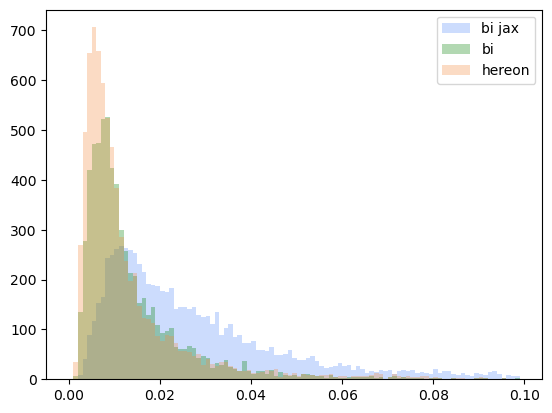

In [55]:
bins = np.arange(0, 0.1, 0.001)
plt.hist(errorDF_bijax.rMAE, bins, alpha=0.3, label='bi jax')
ID = np.logical_not(np.all(Rrs_sim_Arr ==0, axis=1)) # OWT 6 is missing: error during inversion run.
plt.hist(errorDF_bi.rMAE[ID], bins, alpha=0.3, color='green', label='bi')
plt.hist(errorDF_hereon.rMAE, bins, alpha=0.3, label='hereon')
plt.legend()
plt.show()

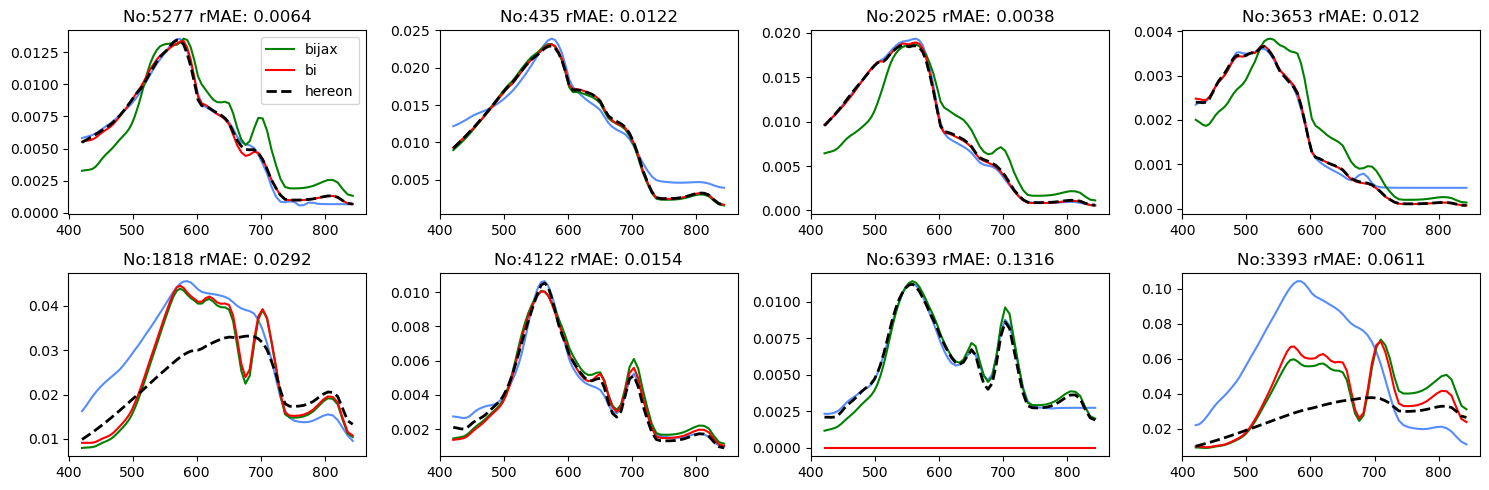

In [57]:
IDgood = errorDF_bi.rMAE.values < 0.015
IDbad = errorDF_bi.rMAE.values > 0.015
N = 4
ind_good = np.random.choice(np.where(IDgood)[0], size=N, replace=False)
ind_bad = np.random.choice(np.where(IDbad)[0], size=N, replace=False)

fig, ax = plt.subplots(nrows=2, ncols=N, figsize=(15, 5))
for ix in range(N):
    ax[0, ix].plot(wavelengths, sp_spectra[valid,:][ind_good[ix],:], '-')
    ax[0, ix].plot(wavelengths, Rrs_sim_jax_Arr[ind_good[ix],:], 'g-', label='bijax')
    ax[0, ix].plot(wavelengths, Rrs_sim_Arr[ind_good[ix],:], 'r-', label='bi')
    ax[0, ix].plot(invWL, invRrs.iloc[ind_good[ix],:], 'k--', lw=2, label='hereon')
    ax[0, ix].set_title('No:' + str(ind_good[ix]) + ' rMAE: '+ str(np.round(errorDF_bi.rMAE.values[ind_good[ix]],4)))

    ax[1, ix].plot(wavelengths, sp_spectra[valid,:][ind_bad[ix],:], '-')
    ax[1, ix].plot(wavelengths, Rrs_sim_jax_Arr[ind_bad[ix],:], 'g-', label='bijax')
    ax[1, ix].plot(wavelengths, Rrs_sim_Arr[ind_bad[ix],:], 'r-', label='bi')
    ax[1, ix].plot(invWL, invRrs.iloc[ind_bad[ix],:], 'k--', lw=2, label='hereon')

    ax[1, ix].set_title('No:' + str(ind_bad[ix]) + ' rMAE: '+ str(np.round(errorDF_bi.rMAE.values[ind_bad[ix]],4)))
    if ix == 0:
        ax[0, ix].legend()
fig.tight_layout()
plt.show()